# Cost function optimization landscape

## Reproduce the original landscape

Here by focusing on the angles between [-pi, pi], we have

In [36]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def reproduce_landscape_fig_2():
    # Setup
    n_global = 20  # Many qubits for global BP
    n_local = 2    # Few qubits for local trainability
    res = 40       # Resolution of the grid
    
    x = np.linspace(-np.pi, np.pi, res)
    y = np.linspace(-np.pi, np.pi, res)
    X, Y = np.meshgrid(x, y)

    def get_landscape(n_qubits, mode="global"):
        dev = qml.device("default.qubit", wires=n_qubits)
        
        @qml.qnode(dev)
        def circuit(phi1, phi2):
            # Simple Hardware Efficient Ansatz
            for i in range(n_qubits):
                qml.RX(phi1, wires=i)
            for i in range(n_qubits - 1):
                qml.CZ(wires=[i, i+1])
            for i in range(n_qubits):
                qml.RX(phi2, wires=i)
            
            if mode == "global":
                # Measure |00...0><00...0|
                return qml.probs(wires=range(n_qubits))
            else:
                # Measure local observable (1/n * sum Z_i)
                return qml.expval(qml.PauliZ(0))

        Z = np.zeros((res, res))
        for i in range(res):
            for j in range(res):
                val = circuit(x[i], y[j])
                # If global, take the probability of the |0...0> state
                Z[i, j] = val[0] if mode == "global" else val
        return Z

    # Generate data
    print("Generating Global Cost landscape (10 qubits)...")
    Z_global = get_landscape(n_global, mode="global")
    
    print("Generating Local Cost landscape (2 qubits)...")
    Z_local = get_landscape(n_local, mode="local")

    # Plotting
    fig = plt.figure(figsize=(14, 6))

    # Global Cost Plot
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(X, Y, Z_global, cmap=cm.coolwarm, antialiased=True)
    ax1.set_title(f"Global Cost ($n={n_global}$)\n'The Narrow Gorge'")
    ax1.set_zlim(0, 1)

    # Local Cost Plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(X, Y, Z_local, cmap=cm.coolwarm, antialiased=True)
    ax2.set_title(f"Local Cost ($n={n_local}$)\n'Trainable Landscape'")
    ax2.set_zlim(-1, 1)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    reproduce_landscape_fig_2()

Generating Global Cost landscape (10 qubits)...


KeyboardInterrupt: 

Here by focusing on the angles between [-pi/2, pi/2], we have

Generating Global Cost landscape (10 qubits)...
Generating Local Cost landscape (2 qubits)...


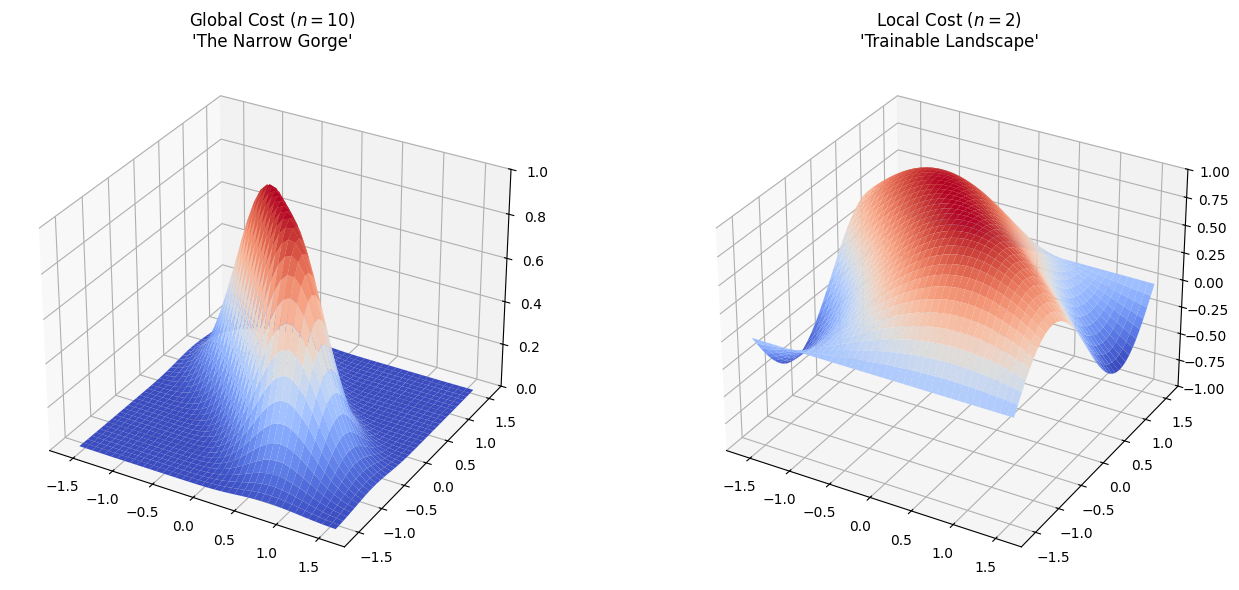

In [10]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def reproduce_landscape_fig_2():
    # Setup
    n_global = 10  # Many qubits for global BP
    n_local = 2    # Few qubits for local trainability
    res = 40       # Resolution of the grid
    
    x = np.linspace(-np.pi/2, np.pi/2, res)
    y = np.linspace(-np.pi/2, np.pi/2, res)
    X, Y = np.meshgrid(x, y)

    def get_landscape(n_qubits, mode="global"):
        dev = qml.device("default.qubit", wires=n_qubits)
        
        @qml.qnode(dev)
        def circuit(phi1, phi2):
            # Simple Hardware Efficient Ansatz
            for i in range(n_qubits):
                qml.RX(phi1, wires=i)
            for i in range(n_qubits - 1):
                qml.CZ(wires=[i, i+1])
            for i in range(n_qubits):
                qml.RX(phi2, wires=i)
            
            if mode == "global":
                # Measure |00...0><00...0|
                return qml.probs(wires=range(n_qubits))
            else:
                # Measure local observable (1/n * sum Z_i)
                return qml.expval(qml.PauliZ(0))

        Z = np.zeros((res, res))
        for i in range(res):
            for j in range(res):
                val = circuit(x[i], y[j])
                # If global, take the probability of the |0...0> state
                Z[i, j] = val[0] if mode == "global" else val
        return Z

    # Generate data
    print("Generating Global Cost landscape (10 qubits)...")
    Z_global = get_landscape(n_global, mode="global")
    
    print("Generating Local Cost landscape (2 qubits)...")
    Z_local = get_landscape(n_local, mode="local")

    # Plotting
    fig = plt.figure(figsize=(14, 6))

    # Global Cost Plot
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(X, Y, Z_global, cmap=cm.coolwarm, antialiased=True)
    ax1.set_title(f"Global Cost ($n={n_global}$)\n'The Narrow Gorge'")
    ax1.set_zlim(0, 1)

    # Local Cost Plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(X, Y, Z_local, cmap=cm.coolwarm, antialiased=True)
    ax2.set_title(f"Local Cost ($n={n_local}$)\n'Trainable Landscape'")
    ax2.set_zlim(-1, 1)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    reproduce_landscape_fig_2()

## Change the cost function to our tilted loss

-0.9956563525735853


<>:53: SyntaxWarning: invalid escape sequence '\g'
<>:53: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_18004\3764244539.py:53: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")


Computing Tilted Loss landscape for n=7...


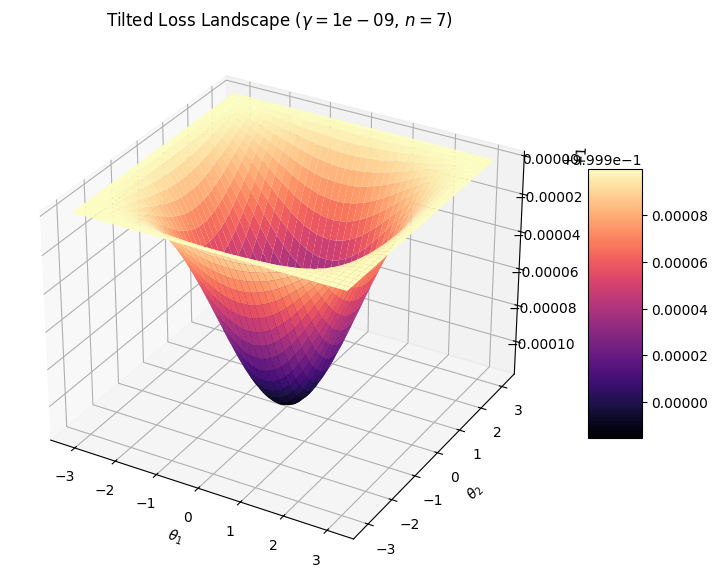

In [58]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import random
from matplotlib import cm


gamma = 0.000000001  # Tilting parameter
res = 120
n_qubits = 7

def tilted_loss(phi1, phi2, other_cos):

    return (1/(-gamma)) * np.log(1 + (np.exp(-gamma) - 1) * (1 - other_cos * (np.cos(phi1 / 2) ** 2) * (np.cos(phi2 / 2) ** 2)))


# Grid for plotting
x = np.linspace(-np.pi, np.pi, res)
y = np.linspace(-np.pi, np.pi, res)

X, Y = np.meshgrid(x, y)
Z = np.zeros((res, res))

print(f"Computing Tilted Loss landscape for n={n_qubits}...")
# for i in range(res):
#     for j in range(res):
#         Tilted_Loss = []
#         for _ in range(100):
#             other_cos = 1
#             for _ in range(n_qubits):
#                 t = random.random() * np.pi * 2 - np.pi
#                 other_cos *= np.cos(t / 2) ** 2
#             Tilted_Loss.append(tilted_loss(x[i], y[j], other_cos))
#         tilted_loss_ave = sum(Tilted_Loss) / 100
#         Z[i, j] = tilted_loss_ave

other_cos = 1
for _ in range(n_qubits):
    # other_cos *= 
    other_cos *= (random.random() * 2 - 1) ** 2

for i in range(res):
    for j in range(res):
        Z[i, j] = tilted_loss(x[i], y[j], other_cos)


# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)

ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
# ax.set_zlim(0, 1)

ax.set_xlabel('$\\theta_1$')
ax.set_ylabel('$\\theta_2$')
plt.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\g'
<>:32: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_18004\1272555842.py:32: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
C:\Users\fff\AppData\Local\Temp\ipykernel_18004\1272555842.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] = tilted_loss(x[i], y[j])


Computing Tilted Loss landscape for n=20...


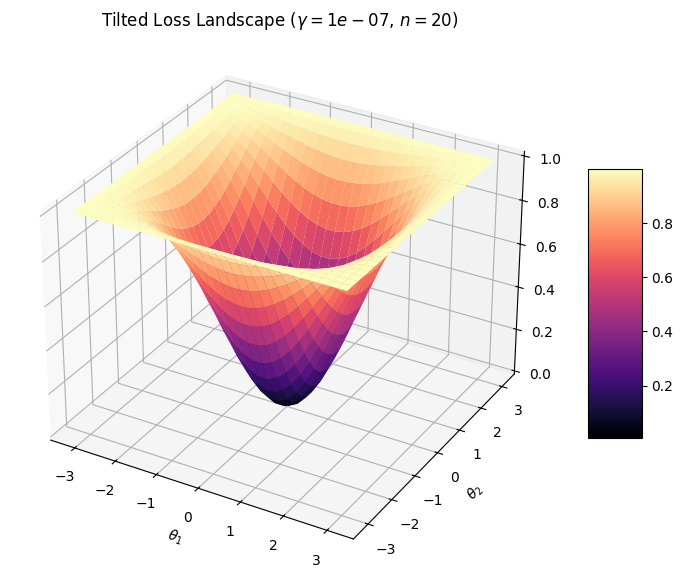

In [37]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 0.0000001  # Tilting parameter
res = 30
n_qubits = 20

def tilted_loss(phi1, phi2):
    return (1/(-gamma) * np.log(1 + (expm(-gamma) - 1) * (1 - (np.cos(phi1 / 2) ** 2) * (np.cos(phi2 / 2) ** 2))))


# Grid for plotting
x = np.linspace(-np.pi, np.pi, res)
y = np.linspace(-np.pi, np.pi, res)
X, Y = np.meshgrid(x, y)
Z = np.zeros((res, res))

print(f"Computing Tilted Loss landscape for n={n_qubits}...")
for i in range(res):
    for j in range(res):

        Z[i, j] = tilted_loss(x[i], y[j])


# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)

ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
ax.set_xlabel('$\\theta_1$')
ax.set_ylabel('$\\theta_2$')
plt.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

large tilting parameter gamma=60, Here by focusing on the angles between [-pi, pi], we have

<>:32: SyntaxWarning: invalid escape sequence '\g'
<>:32: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_8584\709581474.py:32: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
C:\Users\fff\AppData\Local\Temp\ipykernel_8584\709581474.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] = tilted_loss(x[i], y[j])


Computing Tilted Loss landscape for n=10...


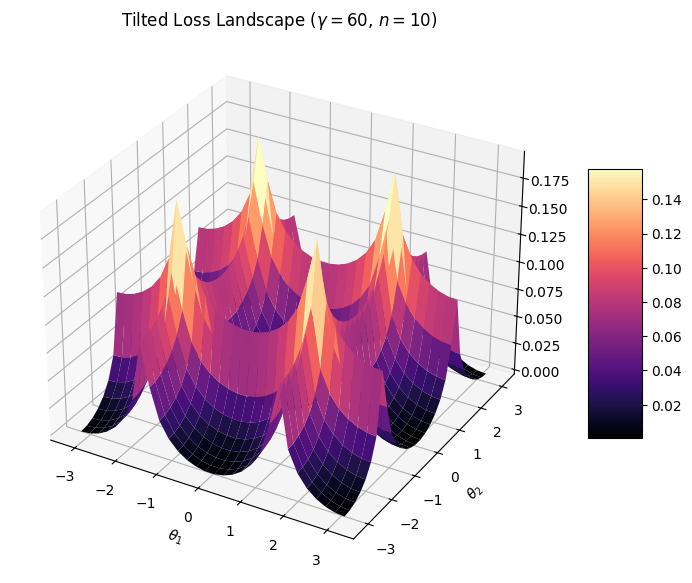

In [22]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 60  # Tilting parameter
res = 30
n_qubits = 10

def tilted_loss(phi1, phi2):
    return (1/(-gamma) * np.log(1 + (expm(-gamma) - 1) * (1 - (np.cos(phi1) ** 2) * (np.cos(phi2) ** 2))))


# Grid for plotting
x = np.linspace(-np.pi, np.pi, res)
y = np.linspace(-np.pi, np.pi, res)
X, Y = np.meshgrid(x, y)
Z = np.zeros((res, res))

print(f"Computing Tilted Loss landscape for n={n_qubits}...")
for i in range(res):
    for j in range(res):

        Z[i, j] = tilted_loss(x[i], y[j])


# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)

ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
ax.set_xlabel('$\\theta_1$')
ax.set_ylabel('$\\theta_2$')
plt.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

large tilting parameter gamma=60, Here by focusing on the angles between [-0.9*pi, 0.9*pi], we have

<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_8584\3057966686.py:55: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")


Computing Tilted Loss landscape for n=10...


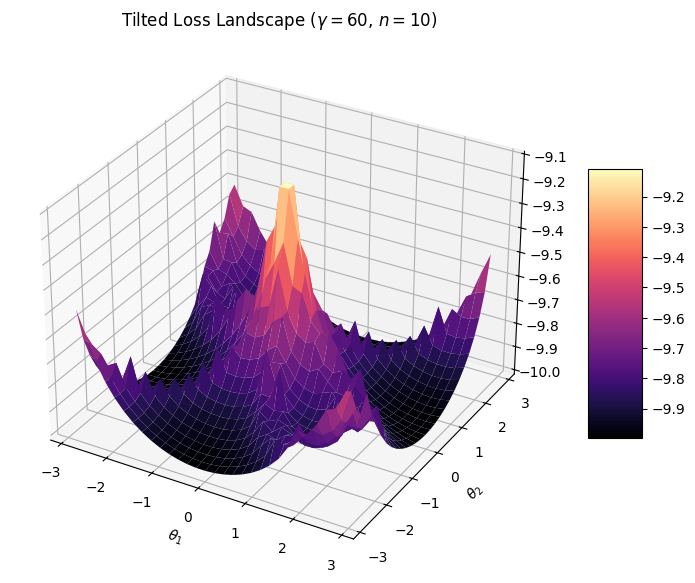

In [3]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 60  # Tilting parameter

def reproduce_tilted_landscape():
    n_qubits = 10
    res = 30
    dev = qml.device("default.qubit", wires=n_qubits)

    # Define a simple Hamiltonian: H = Z0 + Z1 + ... + Zn
    # This is a "Local" Hamiltonian structure
    coeffs = [1.0] * n_qubits
    obs = [qml.PauliZ(i) for i in range(n_qubits)]
    H_matrix = qml.matrix(qml.Hamiltonian(coeffs, obs))
    
    # Pre-compute the operator Exp(-gamma * H)
    exp_H = expm(-gamma * H_matrix)

    @qml.qnode(dev)
    def tilted_circuit(phi1, phi2):
        # Ansatz
        for i in range(n_qubits):
            qml.RY(phi1, wires=i)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i+1])
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        
        # We return the statevector to compute the trace/expectation manually
        return qml.state()

    # Grid for plotting
    x = np.linspace(-np.pi * 0.9, np.pi * 0.9, res)
    y = np.linspace(-np.pi * 0.9, np.pi * 0.9, res)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros((res, res))

    print(f"Computing Tilted Loss landscape for n={n_qubits}...")
    for i in range(res):
        for j in range(res):
            state = tilted_circuit(x[i], y[j])
            # Tr(exp(-gamma*H) * rho) = <psi| exp(-gamma*H) |psi>
            expectation = np.conj(state).T @ exp_H @ state
            # Tilted Loss formula
            Z[i, j] = -(1/gamma) * np.log(np.real(expectation))

    # Plotting
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)
    
    ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
    ax.set_xlabel('$\\theta_1$')
    ax.set_ylabel('$\\theta_2$')
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

if __name__ == "__main__":
    reproduce_tilted_landscape()

Here by focusing on the angles between [-pi/2, pi/2], we have

<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_8584\715994001.py:55: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")


Computing Tilted Loss landscape for n=10...


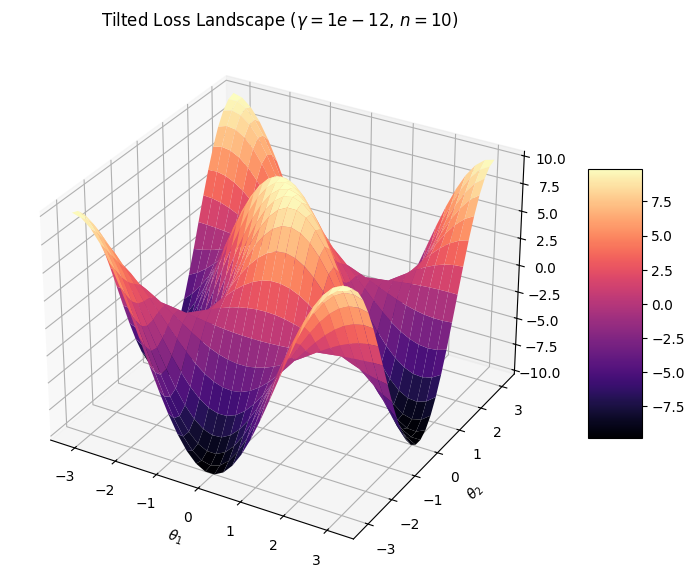

In [7]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 0.000000000001  # Tilting parameter

def reproduce_tilted_landscape():
    n_qubits = 10
    res = 30
    dev = qml.device("default.qubit", wires=n_qubits)

    # Define a simple Hamiltonian: H = Z0 + Z1 + ... + Zn
    # This is a "Local" Hamiltonian structure
    coeffs = [1.0] * n_qubits
    obs = [qml.PauliZ(i) for i in range(n_qubits)]
    H_matrix = qml.matrix(qml.Hamiltonian(coeffs, obs))
    
    # Pre-compute the operator Exp(-gamma * H)
    exp_H = expm(-gamma * H_matrix)

    @qml.qnode(dev)
    def tilted_circuit(phi1, phi2):
        # Ansatz
        for i in range(n_qubits):
            qml.RY(phi1, wires=i)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i+1])
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        
        # We return the statevector to compute the trace/expectation manually
        return qml.state()

    # Grid for plotting
    x = np.linspace(-np.pi, np.pi, res)
    y = np.linspace(-np.pi, np.pi, res)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros((res, res))

    print(f"Computing Tilted Loss landscape for n={n_qubits}...")
    for i in range(res):
        for j in range(res):
            state = tilted_circuit(x[i], y[j])
            # Tr(exp(-gamma*H) * rho) = <psi| exp(-gamma*H) |psi>
            expectation = np.conj(state).T @ exp_H @ state
            # Tilted Loss formula
            Z[i, j] = -(1/gamma) * np.log(np.real(expectation))

    # Plotting
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)
    
    ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
    ax.set_xlabel('$\\theta_1$')
    ax.set_ylabel('$\\theta_2$')
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

if __name__ == "__main__":
    reproduce_tilted_landscape()

<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_7148\658582743.py:55: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")


Computing Tilted Loss landscape for n=6...


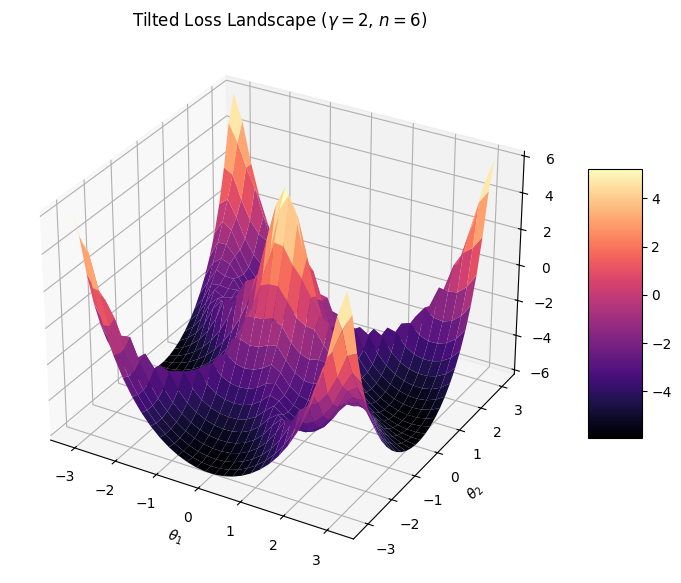

In [8]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 2  # Tilting parameter

def reproduce_tilted_landscape():
    n_qubits = 6
    res = 30
    dev = qml.device("default.qubit", wires=n_qubits)

    # Define a simple Hamiltonian: H = Z0 + Z1 + ... + Zn
    # This is a "Local" Hamiltonian structure
    coeffs = [1.0] * n_qubits
    obs = [qml.PauliZ(i) for i in range(n_qubits)]
    H_matrix = qml.matrix(qml.Hamiltonian(coeffs, obs))
    
    # Pre-compute the operator Exp(-gamma * H)
    exp_H = expm(-gamma * H_matrix)

    @qml.qnode(dev)
    def tilted_circuit(phi1, phi2):
        # Ansatz
        for i in range(n_qubits):
            qml.RY(phi1, wires=i)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i+1])
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        
        # We return the statevector to compute the trace/expectation manually
        return qml.state()

    # Grid for plotting
    x = np.linspace(-np.pi, np.pi, res)
    y = np.linspace(-np.pi, np.pi, res)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros((res, res))

    print(f"Computing Tilted Loss landscape for n={n_qubits}...")
    for i in range(res):
        for j in range(res):
            state = tilted_circuit(x[i], y[j])
            # Tr(exp(-gamma*H) * rho) = <psi| exp(-gamma*H) |psi>
            expectation = np.conj(state).T @ exp_H @ state
            # Tilted Loss formula
            Z[i, j] = -(1/gamma) * np.log(np.real(expectation))

    # Plotting
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)
    
    ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
    ax.set_xlabel('$\\theta_1$')
    ax.set_ylabel('$\\theta_2$')
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

if __name__ == "__main__":
    reproduce_tilted_landscape()

<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
C:\Users\fff\AppData\Local\Temp\ipykernel_7148\2817439296.py:55: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")


Computing Tilted Loss landscape for n=6...


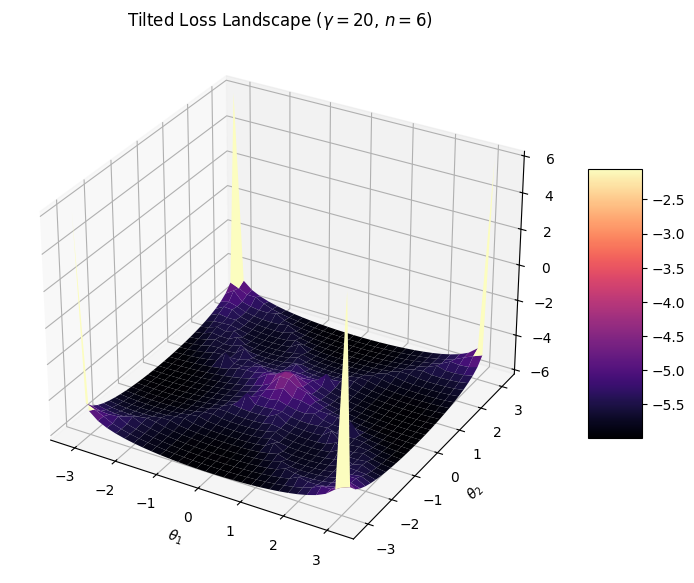

In [9]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

gamma = 20  # Tilting parameter

def reproduce_tilted_landscape():
    n_qubits = 6
    res = 30
    dev = qml.device("default.qubit", wires=n_qubits)

    # Define a simple Hamiltonian: H = Z0 + Z1 + ... + Zn
    # This is a "Local" Hamiltonian structure
    coeffs = [1.0] * n_qubits
    obs = [qml.PauliZ(i) for i in range(n_qubits)]
    H_matrix = qml.matrix(qml.Hamiltonian(coeffs, obs))
    
    # Pre-compute the operator Exp(-gamma * H)
    exp_H = expm(-gamma * H_matrix)

    @qml.qnode(dev)
    def tilted_circuit(phi1, phi2):
        # Ansatz
        for i in range(n_qubits):
            qml.RY(phi1, wires=i)
        for i in range(n_qubits - 1):
            qml.CZ(wires=[i, i+1])
        for i in range(n_qubits):
            qml.RY(phi2, wires=i)
        
        # We return the statevector to compute the trace/expectation manually
        return qml.state()

    # Grid for plotting
    x = np.linspace(-np.pi, np.pi, res)
    y = np.linspace(-np.pi, np.pi, res)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros((res, res))

    print(f"Computing Tilted Loss landscape for n={n_qubits}...")
    for i in range(res):
        for j in range(res):
            state = tilted_circuit(x[i], y[j])
            # Tr(exp(-gamma*H) * rho) = <psi| exp(-gamma*H) |psi>
            expectation = np.conj(state).T @ exp_H @ state
            # Tilted Loss formula
            Z[i, j] = -(1/gamma) * np.log(np.real(expectation))

    # Plotting
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='magma', antialiased=True)
    
    ax.set_title(f"Tilted Loss Landscape ($\gamma={gamma}$, $n={n_qubits}$)")
    ax.set_xlabel('$\\theta_1$')
    ax.set_ylabel('$\\theta_2$')
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

if __name__ == "__main__":
    reproduce_tilted_landscape()

# Numerical simulation